<a href="https://colab.research.google.com/github/BIBEKSHRESTHA08/machine-learning/blob/beginner/Email_Spam_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
# pandas - loads and manages data in table format (DataFrames)

import numpy as np
# numpy - handles numbers and mathematical operations

import matplotlib.pyplot as plt
# matplotlib - creates graphs and charts (used later for plots)

import seaborn as sns
# seaborn - creates statistical visualizations (used for the confusion matrix heatmap)

from sklearn.model_selection import train_test_split
# train_test_split - splits data into training and testing portions

from sklearn.feature_extraction.text import TfidfVectorizer
# TfidfVectorizer - converts text messages into numbers (ML models can't read raw text)

from sklearn.naive_bayes import MultinomialNB
# MultinomialNB - Naive Bayes algorithm, works great for text classification like spam detection

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# accuracy_score - measures how many predictions were correct
# confusion_matrix - shows correct vs incorrect predictions per class
# classification_report - gives precision, recall, and f1-score for each class

In [12]:
import kagglehub
# kagglehub - lets you download datasets directly from Kaggle without manually
# downloading a zip file and uploading it yourself (very useful on Colab,
# since manually uploaded files disappear when the session restarts)

# Download latest version
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")
# dataset_download() fetches the dataset from Kaggle and extracts it automatically
# "uciml/sms-spam-collection-dataset" is the dataset's ID on Kaggle
#   (format is always "owner/dataset-name")
# It returns the folder path where the files were saved - NOT the file itself,
# so you still need to point pandas to the exact file inside that folder

print("Path to dataset files:", path)
# prints the folder location so you can see exactly where the data landed
# you'll need this path in the next step to actually load spam.csv

Using Colab cache for faster access to the 'sms-spam-collection-dataset' dataset.
Path to dataset files: /kaggle/input/sms-spam-collection-dataset


In [13]:
import os
# os - lets Python interact with the operating system, like listing files
# and folders, checking paths, etc.

# see what files are actually inside the downloaded folder
print(os.listdir(path))
# os.listdir(path) returns a list of every file/folder name inside "path"
# this is a good habit whenever you don't know the exact filename in advance -
# instead of guessing, you check first
# for this dataset, it should print something like ['spam.csv']
# if the name is different (or nested in another folder), you'll see it here
# and can adjust the next step accordingly

['spam.csv']


In [14]:
df = pd.read_csv(os.path.join(path, 'spam.csv'), encoding='latin-1')
# os.path.join(path, 'spam.csv') combines the downloaded folder path with the
# filename to build the full, correct file location
# encoding='latin-1' is needed because this dataset contains some special
# characters that the default encoding (utf-8) can't read - without this,
# pandas would throw a UnicodeDecodeError

df = df[['v1', 'v2']]
# the raw CSV has extra unnamed/empty columns we don't need
# this keeps only the 2 useful ones: v1 (label) and v2 (message text)

df.columns = ['label', 'message']
# renames the columns from v1/v2 to clear, meaningful names

df['label'] = df['label'].map({'ham': 0, 'spam': 1})
# ML models need numbers, not text labels
# this converts 'ham' -> 0 and 'spam' -> 1
# map() looks up each value in the dictionary and replaces it accordingly

print(df.head())
# shows the first 5 rows to confirm the data loaded and cleaned correctly

print(df['label'].value_counts())
# counts how many ham (0) vs spam (1) messages exist
# helps you check if the dataset is balanced or imbalanced
# (spam datasets are usually imbalanced - way more ham than spam)

   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...
label
0    4825
1     747
Name: count, dtype: int64


In [15]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=3000)
# TfidfVectorizer converts text messages into numeric vectors, since ML
# models can't work with raw words
# stop_words='english' removes common filler words (the, is, at, and, etc.)
#   that don't help distinguish spam from ham
# max_features=3000 keeps only the 3000 most important/frequent words as
#   columns - this keeps the data manageable instead of using every unique
#   word in the whole dataset

X = vectorizer.fit_transform(df['message'])
# fit_transform() does two things at once:
#   1. "fit" - learns the vocabulary (which 3000 words matter) from the messages
#   2. "transform" - converts every message into a row of TF-IDF scores
# X is now a matrix: each row = one message, each column = one word's
# importance score in that message

y = df['label']
# y holds the target values (0 = ham, 1 = spam) - what we want the model to predict

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
# splits the data into training and testing portions
# X_train, y_train - used to teach the model (80% of the data)
# X_test, y_test   - kept aside to check how well the model performs on
#                    messages it has never seen before
# test_size=0.2 means 20% of the data goes to testing, 80% goes to training
# random_state=42 makes the split reproducible - running this again gives
#   the exact same split every time, instead of a random one

In [17]:
model = MultinomialNB()
# MultinomialNB - Naive Bayes classifier, well suited for text data based on
# word counts/frequencies (like TF-IDF scores)
# it's called "naive" because it assumes all words are independent of each
# other - not technically true in real language, but it works surprisingly
# well for spam detection anyway, and it's fast

model.fit(X_train, y_train)
# this is where the actual learning happens
# the model looks at the training messages (X_train) and their labels
# (y_train), and learns which words are associated with spam vs ham
# for example, it learns that words like "free", "win", "click" appear far
# more often in spam messages than in ham messages

MultinomialNB()

Accuracy: 0.9802690582959641
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       1.00      0.85      0.92       150

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



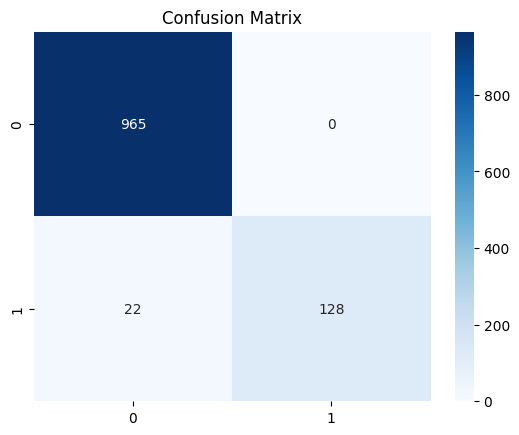

In [18]:
y_pred = model.predict(X_test)
# uses the trained model to predict labels (spam/ham) for the test messages
# it has never seen before
# y_pred now holds the model's guesses, to be compared against the real
# answers in y_test

print("Accuracy:", accuracy_score(y_test, y_pred))
# accuracy_score compares y_pred to the actual y_test labels
# gives the percentage of messages the model classified correctly

print(classification_report(y_test, y_pred))
# gives a detailed breakdown for each class (ham and spam):
#   precision - out of all messages predicted as spam, how many were actually spam
#   recall    - out of all actual spam messages, how many did the model catch
#   f1-score  - balance between precision and recall
# this matters more than accuracy alone here, since the dataset is imbalanced
# (way more ham than spam) - a model could get high accuracy just by
# predicting "ham" every time, without actually catching spam

cm = confusion_matrix(y_test, y_pred)
# builds a table comparing actual vs predicted labels
# rows = actual class, columns = predicted class
# diagonal cells = correct predictions, off-diagonal = mistakes

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
# draws the confusion matrix as a color-coded grid
# annot=True shows the actual numbers inside each cell
# fmt='d' displays them as whole numbers (not decimals)
# cmap='Blues' sets the color scheme

plt.title("Confusion Matrix")
plt.show()
# adds a title and displays the plot

In [19]:
sample = ["Congratulations! You won a free iPhone. Click here now!"]
# a brand-new message, written by you, not from the dataset
# this is the real test - can the model catch spam in the wild?
# note: it must be a list, even for a single message, because vectorizer
# expects a collection of texts, not one raw string

sample_vec = vectorizer.transform(sample)
# converts the new message into the same TF-IDF number format the model
# was trained on
# IMPORTANT: use transform() here, NOT fit_transform()
# fit_transform() would relearn a new vocabulary from just this one message,
# which would break everything - the model only understands the vocabulary
# it was originally trained on

result = model.predict(sample_vec)
# feeds the vectorized message into the trained model
# returns 0 (ham) or 1 (spam) as a prediction

print("Spam" if result[0] == 1 else "Not Spam")
# result[0] gets the single prediction out of the array
# converts the number back into a human-readable label

Spam
